<h1>M3: Model & Evaluation</h1>

<h3>Import Libaries</h3>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

### 1. Define the modeling task
##### Outcome Being Modeled
The outcome (target) variable is **`ev_adpotion_rate`**.
This represents the proportion of residents in each ZIP code who own an electric vehicle (BEV or PHEV).  Using adoption rate instead of raw EV count allows fair comparison across ZIP codes with different population sizes.
#### Type of Prediction
This is a *supervised regression problem*.The model aims to estimate how median household income, population size, and median age influence EV adoption rates across zip codes in Washington State.
I choose the Supervised because the dataset contains labeled outcomes (observed EV adoption rates)and first model is Linear Regression because the target variable (adoption rate) is continuous.

In [15]:
#Load data
df = pd.read_csv("m2output.csv")
#clean feature data first 
#recalculate the ev_adoption_rate
df = df.drop(columns=["ev_adoption_rate"])
#Group by ZIP-level and sum ev_count
df = df.groupby( ["zip_code","county","city", "median_income_household", "population", "median_age"],as_index=False)["ev_count"].sum()
# Re-create EV adoption rate
df["ev_adoption_rate"] = df["ev_count"] / df["population"]
df["population"] = pd.to_numeric(df["population"], errors="coerce")
df = df[df["population"] > 0].copy()
df = df.dropna(subset=["ev_adoption_rate", "median_income_household", "population", "median_age", "zip_code"])
df.head()

,zip_code,county,city,median_income_household,population,median_age,ev_count,ev_adoption_rate
0,98001,King,Auburn,107218,36041,39.9,1207,0.033490
1,98002,King,Auburn,77714,37284,35.6,492,0.013196
2,98003,King,Federal Way,70800,52210,36.4,965,0.018483
3,98004,King,Bellevue,176367,39435,38.4,4003,0.101509
4,98005,King,Bellevue,158396,21929,37.3,2039,0.092982


In [16]:
# target and features
y = df["ev_adoption_rate"]

X = df[[
    "median_income_household",
    "population",
    "median_age",
    "zip_code"
]]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Replace inf/-inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)
X.head()

,median_income_household,population,median_age,zip_code
0,107218,36041,39.9,98001
1,77714,37284,35.6,98002
2,70800,52210,36.4,98003
3,176367,39435,38.4,98004
4,158396,21929,37.3,98005


### 2.Train a baseline model

In [17]:
# Identify categorical and numeric columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

numeric_cols, categorical_cols

(Index(['median_income_household', 'population', 'median_age', 'zip_code'], dtype='object'),
 Index([], dtype='object'))

In [18]:

#  Preprocess: impute + encode
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])


categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [19]:
# Create pipeline with Linear Regression
baseline_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])


#### Model Selection

A **Linear Regression** model is used as the baseline model.

Linear Regression is simple and interpretable.  
It helps quantify how median income, population size, and median age are associated with EV adoption rates.

###### Features Used

- Median household income  
- Population size  
- Median age
- Zip Code

These variables directly match the research question.

In [20]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit + predict
baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Evaluation Metrics
The following regression metrics are used:

- *MAE (Mean Absolute Error)* Average absolute prediction error  
- *RMSE (Root Mean Squared Error)*  Penalizes large errors more  
- *R² (Coefficient of Determination)*  Measures how well the model explains variance  

Lower MAE and RMSE are better.  
Higher R² (closer to 1) is better.

In [21]:
# Evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lr = r2_score(y_test, y_pred)

print("Baseline Model: Linear Regression")
print("MAE:", round(mae_lr, 2))
print("RMSE:", round(rmse_lr, 2))
print("R2:", round(r2_lr, 3))

Baseline Model: Linear Regression
MAE: 0.02
RMSE: 0.03
R2: 0.236


- The MAE of 0.02 means the model’s average prediction error is approximately 2 percentage points in EV adoption rate.
- The RMSE of 0.03 indicates some larger deviations exist but remain relatively small.
- The R² value of 0.236 means that about **23.6% of the variation** in EV adoption rates across ZIP codes is explained by income, population, and median age.
  

### 3. Train an improved model

#### Model Selection
To improve predictive performance, a *Random Forest Regressor* is used.

Random Forest is an ensemble learning method that:
- Captures non-linear relationships
- Handles interaction effects between variables
- Is more flexible than Linear Regression

Because EV adoption patterns may not follow a simple linear trend, a Random Forest model is expected to perform better.

In [22]:
# Improved model pipeline
rf_model = Pipeline(steps=[
    ("preprocessing", preprocessor),   # same preprocessing as baseline
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

# Train model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

#### Evaluation Metrics
The same regression metrics are used for fair comparison:
- *MAE (Mean Absolute Error)*
- *RMSE (Root Mean Squared Error)*
- *R² (Coefficient of Determination)*

In [23]:
# Evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Improved Model: Random Forest")
print("MAE:", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R2:", round(r2_rf, 3))

Improved Model: Random Forest
MAE: 0.02
RMSE: 0.05
R2: -1.883


- The average prediction error is about 0.02, meaning the model’s predictions differ from the actual adoption rate by approximately 1 percentage point on average.
- The RMSE is 0.05, indicating that larger prediction errors are still present.
- The R² value of -1.88 means the model performs worse than predicting the average adoption rate for all ZIP codes.

The Random Forest model does not improve performance over Linear Regression when predicting EV adoption rate. In this case, the simpler Linear Regression model performs better.

### 4.Compare models

| Model | MAE | RMSE | R² |
|-------|------|------|------|
| Linear Regression | 0.02 | 0.03 | 0.236 |
| Random Forest | 0.02 | 0.05 | -1.883 |


Both models show similar MAE and RMSE values.However, the Random Forest model has a negative R² value (-1.883 ), which means it performs worse than simply predicting the average adoption rate.The Linear Regression model, although modest, performs better with an R² of 0.236.

##### Conclusion
The comparison shows that the Random Forest model does not improve predictive performance over the Linear Regression model when predicting EV adoption rate. Although both models have similar MAE and RMSE values, the Linear Regression model achieves a higher R² score (0.236), while the Random Forest model produces a negative R² (-1.883). A negative R² indicates that the Random Forest model performs worse than simply predicting the average adoption rate. This suggests that the relationship between median income, population size, median age, and EV adoption rate may be relatively weak and mostly linear.

### 5. Evaluate with visuals

#### Actual vs Predicted Plot

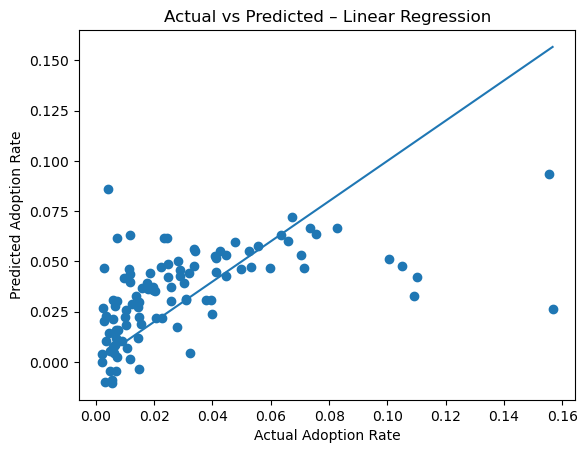

In [11]:
# Use Linear Regression predictions
y_pred = y_pred

plt.figure()
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Adoption Rate")
plt.ylabel("Predicted Adoption Rate")
plt.title("Actual vs Predicted – Linear Regression")
plt.show()

The points are somewhat scattered around the diagonal line, indicating moderate predictive accuracy.The spread of points suggests that the model captures some general trends, but there is still substantial unexplained variation in EV adoption rates.

#### Residuals vs Predicted

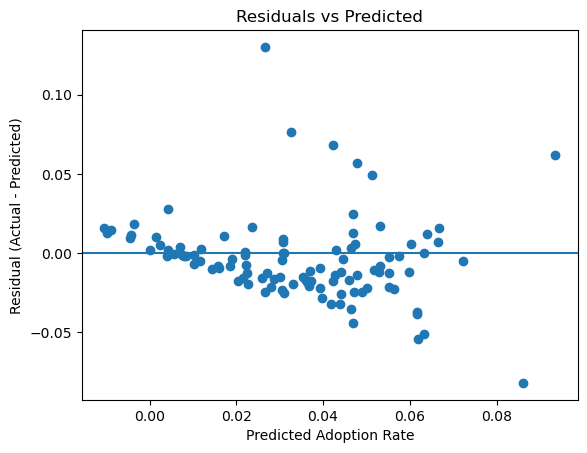

In [12]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)

plt.xlabel("Predicted Adoption Rate")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted")
plt.show()

Residuals are distributed around zero, but there is noticeable spread. This indicates that while the model does not show strong systematic bias, it does not fully explain variability in EV adoption rates.

#### Residual Distribution

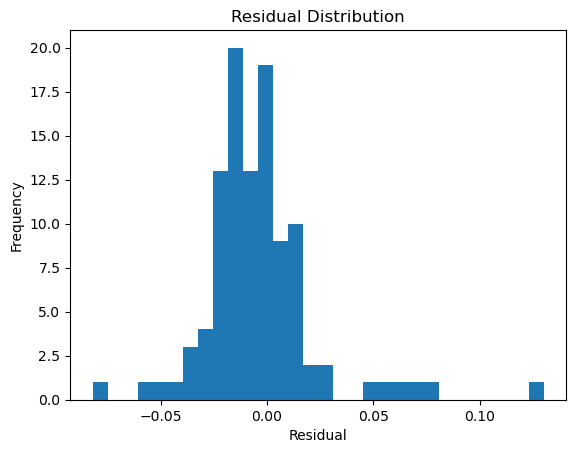

In [13]:
plt.figure()
plt.hist(residuals, bins=30)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

The residuals are centered around zero, suggesting that over- and under-predictions are balanced.However, the distribution shows variability, confirming that additional factors beyond income, population, and median age influence EV adoption.

### 6.Discuss limitations

Several limitations should be considered when interpreting the results:
- *Limited explanatory variables*
   The model only includes median household zip-code, income, population size, and median age.  
   Many important factors are not included, such as:
   - Housing type (single-family vs. multi-unit housing)
   - Urban density
   - Local EV incentives and policies
   - Public transportation access
   - Total nos. of cars registred in the same zip-codes

This likely explains the low R² value (0.236).
- *Cross-sectional data*
   The analysis uses data from a single time period.  
   EV adoption is dynamic and may change over time.
- *ZIP-code aggregation*
   Data is aggregated at the ZIP-code level.  
   This may hide differences within communities (ecological fallacy).

##### Potential Bias
- *Socioeconomic bias*  
   Income is strongly related to EV adoption because EVs are relatively expensive.  However, using income as a predictor may reinforce existing   inequality patterns.
- *Population normalization effects*
   Modeling adoption rate reduces size bias, but small ZIP codes may show unstable rates.

##### Ethical Considerations

This study aims to understand disparities in EV adoption, not to label communities.

Results should be interpreted carefully:
- Lower adoption rates do not reflect lack of interest.
- Structural barriers (infrastructure, housing, affordability) may limit adoption.
- Policymakers should use findings to improve transportation equity, not penalize underserved communities.


##### Overall Conclusion
Socioeconomic and demographic variables explain only a small portion of EV adoption disparities.  Additional structural and policy-related factors likely play a significant role in shaping EV penetration across Washington State.